<a href="https://colab.research.google.com/github/Gabrimoura/Machine-Learning/blob/main/NLP_Text_Classification_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Text Classification with Python

A practical, reusable text-classification pipeline using **TF-IDF + Logistic Regression + scikit-learn**. The project covers preprocessing, training, evaluation and prediction of new text.

> Portfolio project inspired by common freelance NLP tasks. The example dataset is synthetic and is **not** client data.


## 1. Objective
Build a lightweight NLP classifier that receives a text message and automatically assigns it to one of several predefined categories.

Pipeline:
1. Load labeled text data
2. Clean text
3. Split into train/test sets
4. Convert text to TF-IDF features
5. Train a Logistic Regression classifier
6. Evaluate accuracy, precision, recall and F1-score
7. Predict the category of new text


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score


In [ ]:
# Synthetic dataset for demonstration purposes only.
data = [
('I was charged twice for the same order', 'billing'),
('How can I get a copy of my invoice?', 'billing'),
('My payment was declined at checkout', 'billing'),
('I need to update my billing information', 'billing'),
('There is an unexpected charge on my account', 'billing'),
('Why was I charged an extra fee?', 'billing'),
('Can you explain this charge on my card?', 'billing'),
('My invoice has the wrong amount', 'billing'),
('The application crashes when I try to log in', 'technical'),
('The website is not loading correctly', 'technical'),
('I keep getting an error message', 'technical'),
('The app stopped working after the update', 'technical'),
('I cannot upload the required file', 'technical'),
('The button does not respond when I click it', 'technical'),
('The system is very slow today', 'technical'),
('I am having trouble accessing the dashboard', 'technical'),
('How do I reset my password?', 'account'),
('I forgot my username', 'account'),
('I want to change my email address', 'account'),
('How can I close my account?', 'account'),
('I cannot verify my identity', 'account'),
('Where can I change my profile information?', 'account'),
('My account has been locked', 'account'),
('I need help recovering my account', 'account'),
('Where is my package?', 'shipping'),
('My order has not arrived yet', 'shipping'),
('Can I track my delivery?', 'shipping'),
('The package arrived damaged', 'shipping'),
('When will my order be delivered?', 'shipping'),
('My shipment is delayed', 'shipping'),
('The tracking number is not updating', 'shipping'),
('Can I change the delivery address?', 'shipping'),
]

df = pd.DataFrame(data, columns=['text', 'label'])
df.head(), df['label'].value_counts()


(                                          text    label
 0       I was charged twice for the same order  billing
 1          How can I get a copy of my invoice?  billing
 2          My payment was declined at checkout  billing
 3      I need to update my billing information  billing
 4  There is an unexpected charge on my account  billing,
 label
 billing      8
 technical    8
 account      8
 shipping     8
 Name: count, dtype: int64)

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text', 'label']].head()


,text,clean_text,label
0,I was charged twice for the same order,i was charged twice for the same order,billing
1,How can I get a copy of my invoice?,how can i get a copy of my invoice,billing
2,My payment was declined at checkout,my payment was declined at checkout,billing
3,I need to update my billing information,i need to update my billing information,billing
4,There is an unexpected charge on my account,there is an unexpected charge on my account,billing


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.25, random_state=42, stratify=df['label']
)

model = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=1, sublinear_tf=True)),
    ('classifier', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, predictions):.3f}')
print('\nClassification report:\n')
print(classification_report(y_test, predictions))


Accuracy: 0.500

Classification report:

              precision    recall  f1-score   support

     account       0.40      1.00      0.57         2
     billing       1.00      0.50      0.67         2
    shipping       0.00      0.00      0.00         2
   technical       1.00      0.50      0.67         2

    accuracy                           0.50         8
   macro avg       0.60      0.50      0.48         8
weighted avg       0.60      0.50      0.48         8



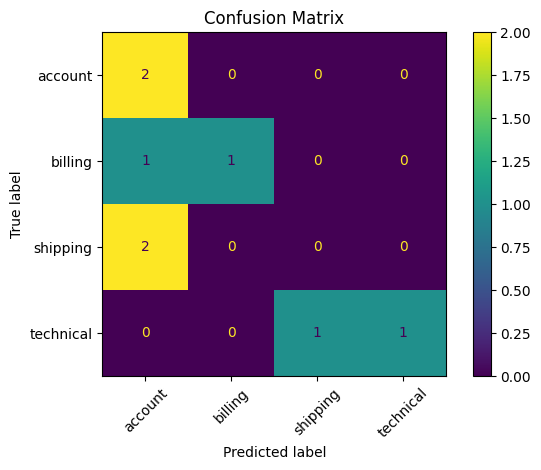

In [ ]:
cm = confusion_matrix(y_test, predictions, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(xticks_rotation=45)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


## 2. Predict new text
The trained pipeline can classify new messages without repeating the preprocessing manually.

In [ ]:
def predict_category(text):
    cleaned = clean_text(text)
    prediction = model.predict([cleaned])[0]
    probabilities = model.predict_proba([cleaned])[0]
    confidence = probabilities.max()
    return prediction, confidence

examples = [
    'My card was charged twice',
    'I cannot log into the application',
    'How do I recover my password?',
    'My package is late'
]

for text in examples:
    category, confidence = predict_category(text)
    print(f'{text} -> {category} (confidence={confidence:.2%})')


My card was charged twice -> billing (confidence=41.51%)
I cannot log into the application -> technical (confidence=35.99%)
How do I recover my password? -> account (confidence=39.45%)
My package is late -> shipping (confidence=41.05%)


## 3. How to adapt this project to a client dataset
For a real freelance project, replace the demonstration dataset with the client's CSV/Excel data containing at least a text column and a target/category column. The pipeline can then be adapted to the client's labels, class balance, language, preprocessing requirements and evaluation criteria.

Possible next steps include hyperparameter tuning, class-weight adjustment, cross-validation, error analysis, model persistence with `joblib`, and a small interface for entering new text.